HEAD:
                            nazwa       stolica   region         subregion  \
0                            Iran        Tehran     Asia     Southern Asia   
1                         Albania        Tirana   Europe  Southeast Europe   
2               Wallis and Futuna      Mata-Utu  Oceania         Polynesia   
3                         Belgium      Brussels   Europe    Western Europe   
4  British Indian Ocean Territory  Diego Garcia   Africa    Eastern Africa   

   populacja  powierzchnia waluta  
0   85961000     1648195.0    IRR  
1    2363314       28748.0    ALL  
2      11620         142.0    XPF  
3   11825551       30528.0    EUR  
4          0          60.0    USD  

SHAPE:
(250, 7)

DTYPES:
nazwa               str
stolica             str
region              str
subregion           str
populacja         int64
powierzchnia    float64
waluta              str
dtype: object

1. Łączna populacja świata:
   total_population
0        8019495460

2. Top 10 krajów wg populacji:


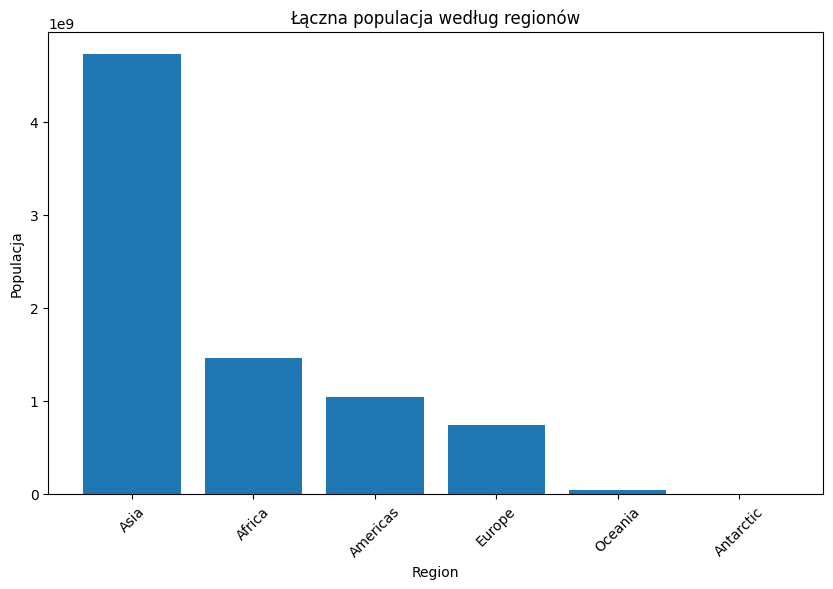

In [5]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

#czesc-1

url = "https://restcountries.com/v3.1/all?fields=name,capital,region,subregion,population,area,currencies"
response = requests.get(url)
data = response.json()

rows = []

for country in data:
    name = country.get("name", {}).get("common")
    
    capital = country.get("capital")
    if isinstance(capital, list) and len(capital) > 0:
        capital = capital[0]
    else:
        capital = None
    
    region = country.get("region")
    subregion = country.get("subregion")
    population = country.get("population")
    area = country.get("area")
    
    currencies = country.get("currencies")
    if currencies:
        currency = list(currencies.keys())[0]
    else:
        currency = None

    rows.append([
        name, capital, region, subregion,
        population, area, currency
    ])

df = pd.DataFrame(rows, columns=[
    "nazwa", "stolica", "region", "subregion",
    "populacja", "powierzchnia", "waluta"
])

print("HEAD:")
print(df.head())

print("\nSHAPE:")
print(df.shape)

print("\nDTYPES:")
print(df.dtypes)

conn = sqlite3.connect("kraje_swiata.db")
df.to_sql("kraje", conn, if_exists="replace", index=False)

print("\n1. Łączna populacja świata:")
print(pd.read_sql_query("""
SELECT SUM(populacja) AS total_population
FROM kraje
""", conn))


print("\n2. Top 10 krajów wg populacji:")
print(pd.read_sql_query("""
SELECT nazwa, populacja
FROM kraje
ORDER BY populacja DESC
LIMIT 10
""", conn))


print("\n3. Regiony — liczba krajów + średnia populacja:")
print(pd.read_sql_query("""
SELECT 
    region,
    COUNT(*) AS liczba_krajow,
    AVG(populacja) AS srednia_populacja
FROM kraje
GROUP BY region
ORDER BY srednia_populacja DESC
""", conn))


print("\n4. Kraje większe niż Polska (~312 679 km²):")
print(pd.read_sql_query("""
SELECT nazwa, powierzchnia
FROM kraje
WHERE powierzchnia > 312679
ORDER BY powierzchnia DESC
""", conn))


print("\n5. Największa gęstość zaludnienia:")
print(pd.read_sql_query("""
SELECT 
    nazwa,
    populacja,
    powierzchnia,
    (populacja * 1.0 / powierzchnia) AS gestosc
FROM kraje
WHERE powierzchnia IS NOT NULL AND powierzchnia > 0
ORDER BY gestosc DESC
LIMIT 1
""", conn))

region_pop = pd.read_sql_query("""
SELECT 
    region,
    SUM(populacja) AS total_population
FROM kraje
GROUP BY region
ORDER BY total_population DESC
""", conn)

plt.figure(figsize=(10,6))
plt.bar(region_pop["region"], region_pop["total_population"])
plt.xticks(rotation=45)
plt.title("Łączna populacja według regionów")
plt.xlabel("Region")
plt.ylabel("Populacja")
plt.show()

conn.close()